# Assignment-2: Implementing and Analyzing Variational Autoencoder (VAE)

**Course:** CS772  
**Submission:** (1) this completed `.ipynb` notebook, and (2) a separate PDF containing all derivations and written answers. The PDF has to be uploaded on **Gradescope** and the notebook has to be uploaded as a **zip file** on the following **Dropbox** link: https://www.dropbox.com/request/br97unrk59kal356hnpf

## Background and Notation

We observe data $x \in \mathbb{R}^D$ and posit a latent variable model:

$$p_\theta(x, z) = p_\theta(x|z)\, p(z)$$

where $p(z) = \mathcal{N}(0, I)$ is a fixed standard normal prior and $p_\theta(x|z)$ is a learned decoder. We want to maximize $\log p_\theta(x)$, but the integral $\int p_\theta(x|z)\,p(z)\,dz$ is intractable.

The VAE (Kingma & Welling, 2013) introduces a learned approximate posterior $q_\phi(z|x) = \mathcal{N}(\mu_\phi(x),\, \mathrm{diag}(\sigma^2_\phi(x)))$, whose parameters are output by an encoder network. Applying Jensen's inequality yields the **Evidence Lower BOund (ELBO)**:

$$\log p_\theta(x) \;\geq\; \underbrace{\mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)]}_{\text{Reconstruction term}} \;-\; \underbrace{D_{\mathrm{KL}}\!\left(q_\phi(z|x) \,\|\, p(z)\right)}_{\text{Regularization term}} \;=:\; \mathcal{L}(\theta, \phi; x)$$

Training maximizes the ELBO jointly over $\theta$ and $\phi$.

> **Notation:** The encoder outputs two $d$-dimensional vectors: $\mu$ (mean) and $\log\sigma^2$ (log-variance `logvar`).

---
## Setup

In [1]:
import torch, random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

SEED = hash("772") % (2**32)
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
Z_DIM      = 10
EPOCHS     = 10
LR         = 1e-3

transform     = transforms.ToTensor()   # pixels in [0, 1]
train_dataset = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)
print(f"Using device: {DEVICE}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 47.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.15MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]

Using device: cpu


---
## Model Architecture

The encoder and decoder are defined as separate modules. The `VAE` class composes them and implements the reparameterization trick.

In [2]:
class Encoder(nn.Module):
    """
    Maps a flat input x (784-d) to the parameters of q_φ(z|x):
    a mean vector μ and a log-variance vector log σ², each of shape (z_dim,).
    """
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
        )
        self.fc_mu     = nn.Linear(256, z_dim)
        self.fc_logvar = nn.Linear(256, z_dim)

    def forward(self, x):
        h = self.net(x.view(-1, 784))
        return self.fc_mu(h), self.fc_logvar(h)

In [3]:
class Decoder(nn.Module):
    """
    Maps a latent vector z (z_dim-d) to a reconstructed image.
    Output is in [0, 1] via sigmoid — interpreted as the mean of p_θ(x|z).
    """
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 784),
            nn.Sigmoid(),    # pixels in [0, 1]
        )

    def forward(self, z):
        return self.net(z).view(-1, 28, 28)

In [4]:
class VAE(nn.Module):
    def __init__(self, z_dim=Z_DIM):
        super().__init__()
        self.encoder = Encoder(z_dim)
        self.decoder = Decoder(z_dim)

    def reparameterize(self, mu, logvar):
        """
        TODO (Q2.1): Implement the reparameterization trick.

        Draw z ~ q_φ(z|x) = N(μ, diag(σ²)) in a way that allows
        gradients to flow back through z into μ and log σ².

        """
        std = torch.exp(0.5 * logvar)
        # sample epsilon from standard normal distribution
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z          = self.reparameterize(mu, logvar)
        recon_x    = self.decoder(z)
        return recon_x, mu, logvar, z

---
## Part 1

### Q1.1  Reconstruction Loss (10 pts)

Assume the decoder models $p_\theta(x|z) = \mathcal{N}(f_\theta(z), \sigma^2 I)$, where $f_\theta(z)$ is the decoder output and $\sigma^2$ is a fixed constant.

1. Show algebraically that maximizing $\log p_\theta(x|z)$ under this Gaussian assumption is equivalent to minimizing the Mean Squared Error (MSE) between $x$ and $f_\theta(z)$.*

2. In practice we implement a deterministic decoder. The network outputs only the mean $f_\theta(z)$ and the variance is ignored. Briefly explain what this implies about the quality of VAE-generated images.

3. An alternative is to model each pixel as an independent Bernoulli: $p_\theta(x|z) = \prod_i \text{Bern}(x_i;\, \hat{x}_i)$. What loss function does this correspond to? Why might this be more principled for MNIST than MSE?

### Q1.2  Closed-Form KL Divergence (10 pts)

Given $q_\phi(z|x) = \mathcal{N}(\mu, \mathrm{diag}(\sigma^2))$ and $p(z) = \mathcal{N}(0, I)$, derive the following closed-form expression starting only from the definition of KL divergence:

$$D_{\mathrm{KL}}\!\left(q_\phi(z|x) \,\|\, p(z)\right) = -\frac{1}{2}\sum_{j=1}^{d}\left(1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2\right)$$


---
## Part 2  Implementation

### Q2.1  Reparameterization (5 pts)

Implement `reparameterize` in the `VAE` class above and explain why this trick is necessary. What goes wrong if you write `z = torch.distributions.Normal(mu, sigma).sample()` and try to backpropagate.

### Q2.2  Loss Function (10 pts)

Implement the VAE loss below. Use **MSE** for the reconstruction term and the **closed-form KL** from Q1.2.

> **Reduction:** use `.sum(dim=1).mean()` — sum over pixels and latent dimensions, then average over the batch.

In [5]:
def vae_loss(recon_x, x, mu, logvar):
    """
    VAE ELBO loss (negated — we minimize this).

    Args:
        recon_x : (B, 784)        decoder output, pixel values in [0, 1]
        x       : (B, 1, 28, 28)  original images
        mu      : (B, z_dim)
        logvar  : (B, z_dim)      log σ²

    Returns:
        recon_l : scalar reconstruction term
        kl_l    : scalar KL term
    """
    # Flatten BOTH the original images and the reconstructed images to (B, 784)
    x_flat = x.view(-1, 784)
    recon_x_flat = recon_x.view(-1, 784)

    # MSE
    recon_l = F.mse_loss(recon_x_flat, x_flat, reduction='none').sum(dim=1).mean()

    # Closed-form KL
    kl_l = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()

    return recon_l, kl_l

### Q2.3  Training Loop (5 pts)

Implement the training loop below. Log total loss, reconstruction loss, and KL loss separately each epoch. After training, plot all three on a single figure.

In [6]:
def train(model, optimizer, loss_fn, loader, epochs=EPOCHS, beta=1.0):
    model.train()
    ### Implementation
    history = {'total': [], 'recon': [], 'kl': []}

    for epoch in range(epochs):
        epoch_total = 0.0
        epoch_recon = 0.0
        epoch_kl = 0.0

        for batch_idx, (data, _) in enumerate(loader):
            data = data.to(DEVICE)

            optimizer.zero_grad()

            recon_batch, mu, logvar, z = model(data)

            recon_loss, kl_loss = loss_fn(recon_batch, data, mu, logvar)

            # We minimize -ELBO = -recon_loss + KL loss = +MSE + KL loss
            loss = recon_loss + beta * kl_loss
            loss.backward()
            optimizer.step()

            epoch_total += loss.item()
            epoch_recon += recon_loss.item()
            epoch_kl += kl_loss.item()

        # Average over batches
        history['total'].append(epoch_total / len(loader))
        history['recon'].append(epoch_recon / len(loader))
        history['kl'].append(epoch_kl / len(loader))

        print(f"Epoch {epoch+1}/{epochs} | Loss: {history['total'][-1]:.4f} "
              f"(Recon: {history['recon'][-1]:.4f}, KL: {history['kl'][-1]:.4f})")

    return history

Epoch 1/10 | Loss: 46.8236 (Recon: 43.2458, KL: 3.5777)
Epoch 2/10 | Loss: 34.1903 (Recon: 26.5914, KL: 7.5988)
Epoch 3/10 | Loss: 32.2451 (Recon: 23.8811, KL: 8.3640)
Epoch 4/10 | Loss: 31.1016 (Recon: 22.2412, KL: 8.8604)
Epoch 5/10 | Loss: 30.3817 (Recon: 21.1759, KL: 9.2058)
Epoch 6/10 | Loss: 29.8623 (Recon: 20.4057, KL: 9.4566)
Epoch 7/10 | Loss: 29.4811 (Recon: 19.8654, KL: 9.6157)
Epoch 8/10 | Loss: 29.1639 (Recon: 19.4255, KL: 9.7384)
Epoch 9/10 | Loss: 28.9269 (Recon: 19.0689, KL: 9.8580)
Epoch 10/10 | Loss: 28.6953 (Recon: 18.7840, KL: 9.9113)


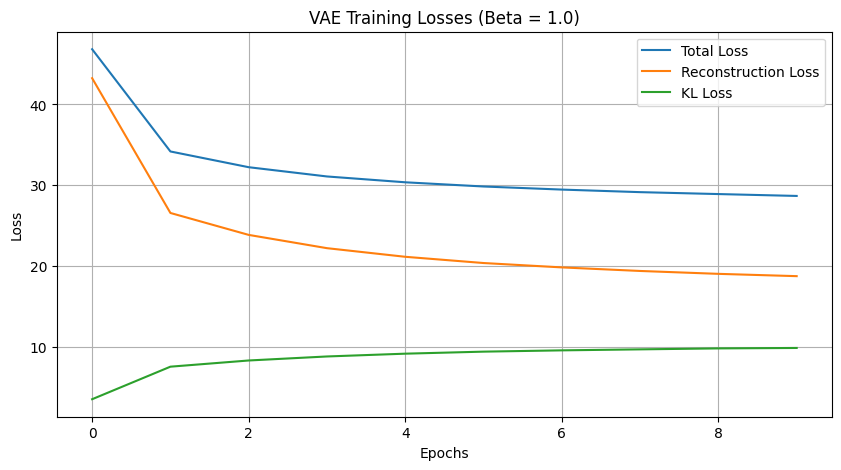

In [7]:
# Training the standard model (β = 1)
model     = VAE().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LR)
history_standard = train(model, optimizer, vae_loss, train_loader)

# Graphs
plt.figure(figsize=(10, 5))
plt.plot(history_standard['total'], label='Total Loss')
plt.plot(history_standard['recon'], label='Reconstruction Loss')
plt.plot(history_standard['kl'], label='KL Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('VAE Training Losses (Beta = 1.0)')
plt.legend()
plt.grid(True)
plt.show()

### Q2.4  Monte Carlo KL Approximation (15 pts)

The KL term can be estimated without a closed form using Monte Carlo (MC) sampling:

$$D_{\mathrm{KL}}(q_\phi(z|x) \| p(z)) = \mathbb{E}_{q_\phi(z|x)}\!\left[\log q_\phi(z|x) - \log p(z)\right] \approx \frac{1}{L}\sum_{\ell=1}^{L}\left[\log q_\phi(z^{(\ell)}|x) - \log p(z^{(\ell)})\right]$$

where each $z^{(\ell)} \sim q_\phi(z|x)$ is drawn using the reparameterization trick.

1. Implement `vae_loss_mc` below. Draw $L$ samples *inside* the loss function. Use `torch.distributions.Normal` for the log-probability evaluations.
2. Train three fresh models using `vae_loss_mc` with $L \in \{1, 10, 100\}$. Plot the KL loss curves for all three alongside your closed-form baseline.
3.Describe qualitatively what you observe in the $L=1$ KL curve compared to $L=100$. Why is high variance in this gradient estimate specifically harmful during early training? Why would you prefer the closed form when it is available, even if $L$ is large?

In [8]:
def vae_loss_mc(recon_x, x, mu, logvar, L=1):
    """
    VAE loss with MC-estimated KL using L samples.

    Args:
        recon_x : (B, 784)
        x       : (B, 1, 28, 28)
        mu      : (B, z_dim)
        logvar  : (B, z_dim)
        L       : number of MC samples for the KL estimate

    Returns: (recon_l, kl_l)

    Hint: draw samples of shape (L, B, z_dim) using the reparameterization
    trick, evaluate log q and log p for each, and average over L.
    """
    std = torch.exp(0.5 * logvar)

    # Reconstruction Loss
    x_flat = x.view(-1, 784)
    recon_x_flat = recon_x.view(-1, 784)
    recon_l = F.mse_loss(recon_x_flat, x_flat, reduction='none').sum(dim=1).mean()

    # L samples of noise: shape (L, B, z_dim)
    eps = torch.randn(L, mu.size(0), mu.size(1), device=mu.device)

    # Reparameterize
    z_samples = mu.unsqueeze(0) + eps * std.unsqueeze(0)

    # KL loss
    dist_q = torch.distributions.Normal(mu.unsqueeze(0), std.unsqueeze(0))
    dist_p = torch.distributions.Normal(torch.zeros_like(z_samples), torch.ones_like(z_samples))
    log_q = dist_q.log_prob(z_samples).sum(dim=-1)
    log_p = dist_p.log_prob(z_samples).sum(dim=-1)

    kl_l = (log_q - log_p).mean(dim=0).mean()

    return recon_l, kl_l


--- Training MC VAE with L = 1 ---
Epoch 1/10 | Loss: 47.2611 (Recon: 43.9376, KL: 3.3235)
Epoch 2/10 | Loss: 34.4626 (Recon: 26.8751, KL: 7.5875)
Epoch 3/10 | Loss: 32.1084 (Recon: 23.5382, KL: 8.5703)
Epoch 4/10 | Loss: 31.1469 (Recon: 22.1752, KL: 8.9717)
Epoch 5/10 | Loss: 30.5098 (Recon: 21.3018, KL: 9.2079)
Epoch 6/10 | Loss: 30.0388 (Recon: 20.6390, KL: 9.3998)
Epoch 7/10 | Loss: 29.6399 (Recon: 20.1074, KL: 9.5325)
Epoch 8/10 | Loss: 29.3636 (Recon: 19.6847, KL: 9.6789)
Epoch 9/10 | Loss: 29.0885 (Recon: 19.3364, KL: 9.7521)
Epoch 10/10 | Loss: 28.8859 (Recon: 19.0174, KL: 9.8685)

--- Training MC VAE with L = 10 ---
Epoch 1/10 | Loss: 46.0750 (Recon: 42.2424, KL: 3.8326)
Epoch 2/10 | Loss: 33.9850 (Recon: 26.0443, KL: 7.9408)
Epoch 3/10 | Loss: 31.7561 (Recon: 22.8058, KL: 8.9503)
Epoch 4/10 | Loss: 30.6422 (Recon: 21.1930, KL: 9.4492)
Epoch 5/10 | Loss: 30.0087 (Recon: 20.2567, KL: 9.7520)
Epoch 6/10 | Loss: 29.5633 (Recon: 19.6117, KL: 9.9516)
Epoch 7/10 | Loss: 29.2173 (Re

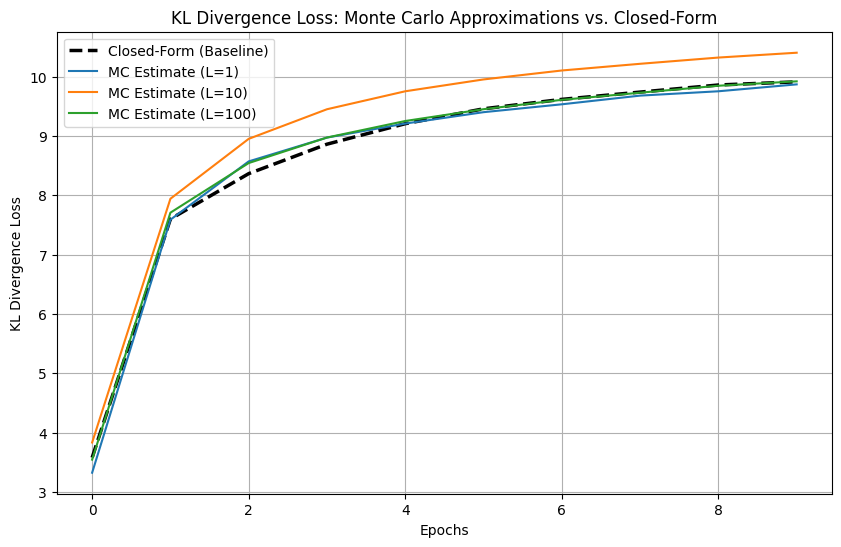

In [9]:


# Train with L = 1, 10, 100 and plot KL curves
# YOUR CODE HERE
L_vals = [1, 10, 100]
mc_histories = {}

for L in L_vals:
    print(f"\n--- Training MC VAE with L = {L} ---")
    # Fresh models which use no previous knowledge.
    model_mc = VAE().to(DEVICE)
    optimizer_mc = optim.Adam(model_mc.parameters(), lr=LR)

    # Wraping the MC loss function in a lambda to pass the specific L value at the end of
    # loss_fn in the train function
    loss_fn_mc = lambda recon_x, x, mu, logvar: vae_loss_mc(recon_x, x, mu, logvar, L=L)

    history_mc = train(model_mc, optimizer_mc, loss_fn_mc, train_loader)
    mc_histories[L] = history_mc

# Plotiting graphs
plt.figure(figsize=(10, 6))
plt.plot(history_standard['kl'], label='Closed-Form (Baseline)', linewidth=2.5, linestyle='--', color='black')

for L in L_vals:
    plt.plot(mc_histories[L]['kl'], label=f'MC Estimate (L={L})')

plt.xlabel('Epochs')
plt.ylabel('KL Divergence Loss')
plt.title('KL Divergence Loss: Monte Carlo Approximations vs. Closed-Form')
plt.legend()
plt.grid(True)
plt.show()

---
## Part 3  $\beta$-VAE and Posterior Collapse

We introduce a scalar $\beta \geq 0$ weighting the KL term:

$$\mathcal{L}_\beta = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - \beta \cdot D_{\mathrm{KL}}(q_\phi(z|x) \| p(z))$$

The standard VAE is $\beta = 1$. Higgins et al. (2017) showed $\beta > 1$ encourages disentangled representations at the cost of reconstruction quality.

### Q3.1  Training (5 pts)

Modify your training loop to accept `beta`. Train three models with $\beta \in \{0.1, 1.0, 10.0\}$ for `EPOCHS` epochs. Show plots of the reconstruction and KL loss curves for all three settings.


--- Training Beta-VAE with beta = 0.1 ---
Epoch 1/10 | Loss: 37.8081 (Recon: 36.3075, KL: 15.0060)
Epoch 2/10 | Loss: 19.5679 (Recon: 17.1048, KL: 24.6309)
Epoch 3/10 | Loss: 16.8448 (Recon: 14.3261, KL: 25.1871)
Epoch 4/10 | Loss: 15.6394 (Recon: 13.0992, KL: 25.4019)
Epoch 5/10 | Loss: 14.9095 (Recon: 12.3552, KL: 25.5438)
Epoch 6/10 | Loss: 14.3633 (Recon: 11.7987, KL: 25.6462)
Epoch 7/10 | Loss: 13.9492 (Recon: 11.3756, KL: 25.7356)
Epoch 8/10 | Loss: 13.6162 (Recon: 11.0334, KL: 25.8278)
Epoch 9/10 | Loss: 13.3304 (Recon: 10.7364, KL: 25.9395)
Epoch 10/10 | Loss: 13.1007 (Recon: 10.4995, KL: 26.0122)

--- Training Beta-VAE with beta = 1.0 ---
Epoch 1/10 | Loss: 46.5613 (Recon: 42.8974, KL: 3.6639)
Epoch 2/10 | Loss: 34.4870 (Recon: 27.0363, KL: 7.4507)
Epoch 3/10 | Loss: 32.5244 (Recon: 24.4184, KL: 8.1060)
Epoch 4/10 | Loss: 31.5556 (Recon: 23.1051, KL: 8.4505)
Epoch 5/10 | Loss: 30.8839 (Recon: 22.2206, KL: 8.6634)
Epoch 6/10 | Loss: 30.4196 (Recon: 21.5805, KL: 8.8391)
Epoch 7

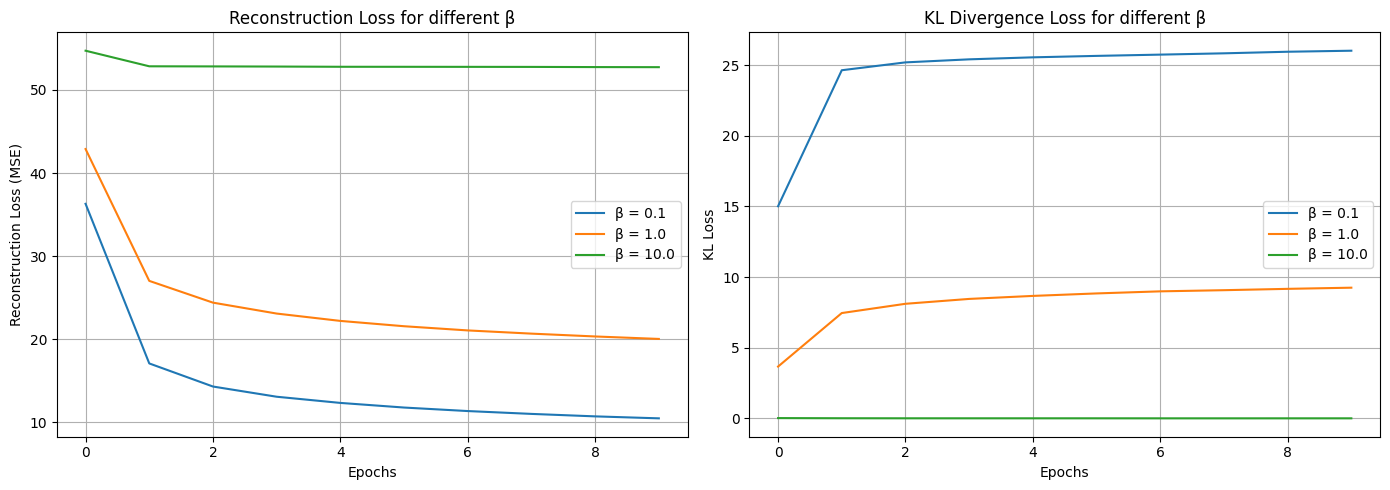

In [10]:
betas    = [0.1, 1.0, 10.0]
beta_models = {}
histories = {}

for beta in betas:
    # YOUR CODE HERE
    print(f"\n--- Training Beta-VAE with beta = {beta} ---")
    model_beta = VAE().to(DEVICE)
    optimizer_beta = optim.Adam(model_beta.parameters(), lr=LR)

    history_beta = train(model_beta, optimizer_beta, vae_loss, train_loader, epochs=EPOCHS, beta=beta)

    histories[beta] = history_beta
    beta_models[beta] = model_beta

# Plot reconstruction and KL loss curves for all three β values
# YOUR PLOT HERE
plt.figure(figsize=(14, 5))

# Plot 1: Reconstruction Loss
plt.subplot(1, 2, 1)
for beta in betas:
    plt.plot(histories[beta]['recon'], label=f'β = {beta}')
plt.title('Reconstruction Loss for different β')
plt.xlabel('Epochs')
plt.ylabel('Reconstruction Loss (MSE)')
plt.legend()
plt.grid(True)

# Plot 2: KL Divergence Loss
plt.subplot(1, 2, 2)
for beta in betas:
    plt.plot(histories[beta]['kl'], label=f'β = {beta}')
plt.title('KL Divergence Loss for different β')
plt.xlabel('Epochs')
plt.ylabel('KL Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Q3.2 — Posterior Collapse Analysis (15 pts)

Posterior collapse occurs when the encoder ignores the input and maps everything to the prior: $q_\phi(z|x) \approx p(z)$ regardless of $x$.

1. For each trained model, use `compute_active_dims` below to compute the per-dimension variance of the encoder means across the test set.
2. For each $\beta$, show a plot of the per-dimension variance across all 10 latent dimensions.
3. What happens to the latent dimensions under $\beta = 10.0$? Provide a explanation why does a large $\beta$ incentivize the encoder to ignore the input? Why does the decoder then receive no useful signal from those dimensions?

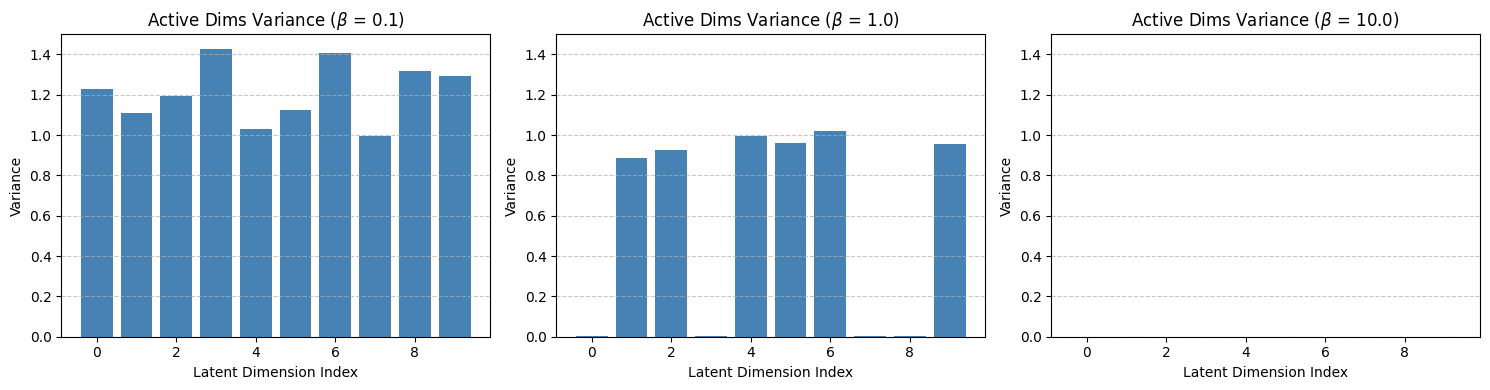

In [11]:
def compute_active_dims(model, loader, device=DEVICE):
    """
    Returns: (z_dim,) tensor — per-dimension variance of encoder means
    across the test set.
    """
    model.eval()
    all_mu = []
    with torch.no_grad():
        for x, _ in loader:
            mu, _ = model.encoder(x.to(device))
            all_mu.append(mu.cpu())
    all_mu = torch.cat(all_mu, dim=0)   # (N_test, z_dim)
    return all_mu.var(dim=0)            # (z_dim,)

# Compute and plot active dimensions for each β
# YOUR CODE HERE
plt.figure(figsize=(15, 4))

for i, beta in enumerate(betas):
    # Using the models we saved in Q3.1
    active_vars = compute_active_dims(beta_models[beta], test_loader)

    plt.subplot(1, 3, i+1)
    plt.bar(range(Z_DIM), active_vars.numpy(), color='steelblue')
    plt.title(f'Active Dims Variance ($\\beta$ = {beta})')
    plt.xlabel('Latent Dimension Index')
    plt.ylabel('Variance')
    # A fixed y scale
    plt.ylim(0, 1.5)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## Part 4  Geometry of the Latent Space

### Q4.1  Linear Interpolation (15 pts)

A well-trained VAE should produce a smooth, connected latent space: nearby points in $\mathbb{R}^d$ should decode to semantically similar images.

Using your $\beta = 1.0$ model:

1. Pick one test image of digit "2" and one of digit "7". Pass each through the encoder and record the **mean vectors** $\mu_A$ and $\mu_B$ (use the mean, not a sample).
2. Generate 10 interpolated latent vectors: $z_t = (1-t)\,\mu_A + t\,\mu_B,\quad t \in \{0.0,\,0.1,\,\ldots,\,1.0\}$
3. Decode each $z_t$ and display the resulting images.
4. Do you observe a smooth semantic transition? Describe what the intermediate images look like. Why does the KL regularization term play a direct role in enabling this, while a standard Autoencoder (no KL term) would not guarantee it?

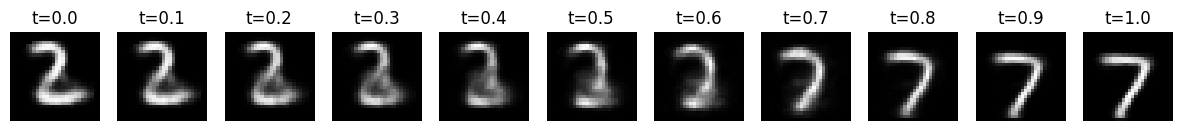

In [12]:
# YOUR CODE HERE
# Get a batch of test data
model = beta_models[1.0] # Use the standard VAE
model.eval()

data_iter = iter(test_loader)
images, labels = next(data_iter)

idx_2 = (labels == 2).nonzero(as_tuple=True)[0][0]
idx_7 = (labels == 7).nonzero(as_tuple=True)[0][0]

img_A = images[idx_2].unsqueeze(0).to(DEVICE)
img_B = images[idx_7].unsqueeze(0).to(DEVICE)

# Since we don't want the model to track gradients
with torch.no_grad():
    mu_A, _ = model.encoder(img_A)
    mu_B, _ = model.encoder(img_B)

# Generate interpolated latents
steps = 11
ts = torch.linspace(0, 1, steps).unsqueeze(1).to(DEVICE) # (11, 1)

# Linear interpolation formula
z_interp = (1 - ts) * mu_A + ts * mu_B

with torch.no_grad():
    recon_interp = model.decoder(z_interp).cpu()

# Plot results
plt.figure(figsize=(15, 3))
for i in range(steps):
    plt.subplot(1, steps, i+1)
    plt.imshow(recon_interp[i].view(28, 28).numpy(), cmap='gray')
    plt.title(f't={ts[i].item():.1f}')
    plt.axis('off')
plt.show()

### Q4.2 — 2-D Latent Space Visualization *(Bonus, 10 pts)*

Retrain a VAE with `Z_DIM = 2`. Encode the full test set, collect all $\mu$ vectors, and plot them colored by digit class. Describe the structure: are digit classes separated? Do visually similar digits cluster near each other?

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7569/921591847.py:40: SyntaxWarning: invalid escape sequence '\m'
  plt.title('2D Latent Space Visualization of MNIST ($\mu$ vectors)')


--- Training 2D VAE for Visualization ---
Epoch 1/10 | Loss: 48.6924 (Recon: 46.5393, KL: 2.1531)
Epoch 2/10 | Loss: 40.7579 (Recon: 37.0517, KL: 3.7062)
Epoch 3/10 | Loss: 38.9767 (Recon: 34.8529, KL: 4.1238)
Epoch 4/10 | Loss: 38.0362 (Recon: 33.6590, KL: 4.3772)
Epoch 5/10 | Loss: 37.3157 (Recon: 32.7415, KL: 4.5742)
Epoch 6/10 | Loss: 36.7087 (Recon: 31.9726, KL: 4.7361)
Epoch 7/10 | Loss: 36.3210 (Recon: 31.4836, KL: 4.8374)
Epoch 8/10 | Loss: 35.9395 (Recon: 31.0304, KL: 4.9092)
Epoch 9/10 | Loss: 35.6346 (Recon: 30.6441, KL: 4.9905)
Epoch 10/10 | Loss: 35.4030 (Recon: 30.3513, KL: 5.0517)


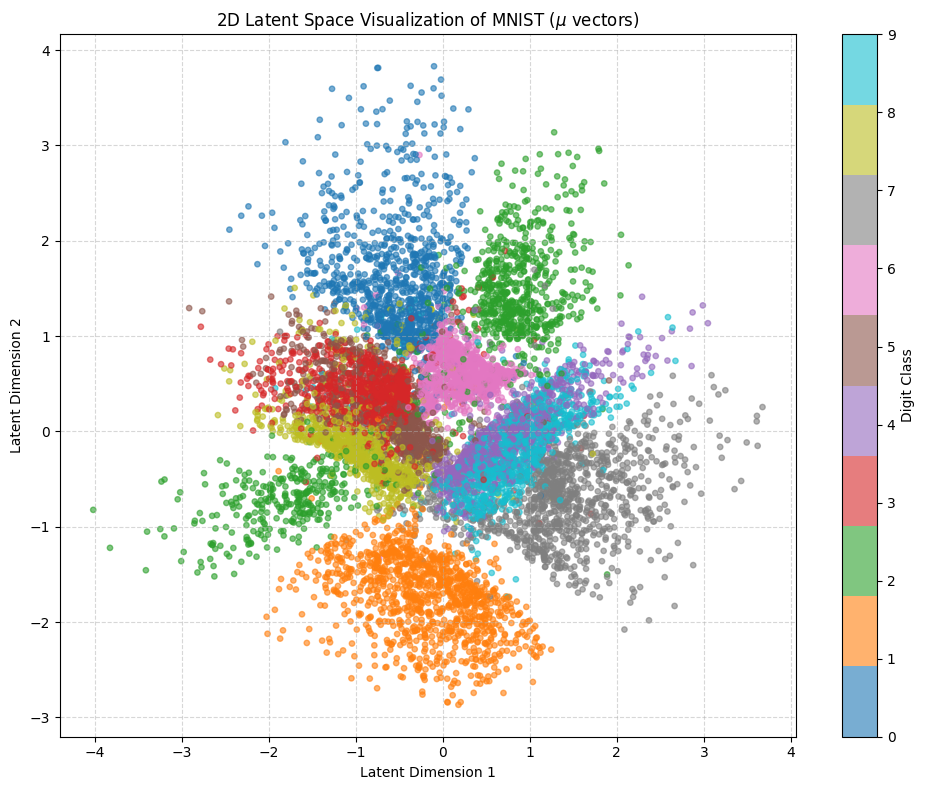

In [13]:
# YOUR CODE HERE
print("--- Training 2D VAE for Visualization ---")
model_2d = VAE(z_dim=2).to(DEVICE)
optimizer_2d = optim.Adam(model_2d.parameters(), lr=LR)

history_2d = train(model_2d, optimizer_2d, vae_loss, train_loader, epochs=EPOCHS, beta=1.0)

# Encode the full test set
model_2d.eval()
all_mu_2d = []
all_labels = []

with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(DEVICE)

        mu, _ = model_2d.encoder(data)

        all_mu_2d.append(mu.cpu())
        all_labels.append(labels)

# Concatenate into single tensors and convert to numpy for plotting
all_mu_2d = torch.cat(all_mu_2d, dim=0).numpy()
all_labels = torch.cat(all_labels, dim=0).numpy()

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    all_mu_2d[:, 0],
    all_mu_2d[:, 1],
    c=all_labels,
    cmap='tab10',
    alpha=0.6,
    s=15
)

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Digit Class')

plt.title('2D Latent Space Visualization of MNIST ($\mu$ vectors)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

---
## References

- Kingma, D. P. & Welling, M. (2013). *Auto-Encoding Variational Bayes.* ICLR 2014. arXiv:1312.6114  
- Higgins, I. et al. (2017). *β-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework.* ICLR 2017.  
- Lucas, J. et al. (2019). *Don't Blame the ELBO! A Linear VAE Perspective on Posterior Collapse.* NeurIPS 2019.